In [13]:
## Loading required Libraries
import pandas as pd
import numpy as np

In [185]:
# Loading data 
df = pd.read_csv('C:/Users/UserIBM/Documents/Enischyo Intership/Pakistani job postings.csv') 

In [15]:
df.head()

,Job Name,label,Company Name,Job Type,Experience Required,Department,JD,City,Date Posted
0,"Full Time New Job Positions .Net, .Netcore, Fl...",Premium Job,"Nayel Solutions, Pakistan",Full Time Jobs,2 Years Job Exp.,IT Jobs,"New Job Positions .net, .netcore, flutter, Tea...",Islamabad,12-Mar-21
1,Full Time Senior Web Developer Jobs in Pakistan,Premium Job,"Eurosoft Tech Private Limited, Pakistan",Full Time Jobs,2 Years Job Exp.,IT Jobs,We are looking for an experienced Web Develope...,Karachi,12-Mar-21
2,Full Time Russian Speakers Jobs in Pakistan,Premium Job,"ICM JAPAN, Pakistan",Full Time Jobs,< 1 Year,Customer Service Jobs,International clients dealing exposure (B2B).S...,Karachi,12-Mar-21
3,Full Time Customer Support Specialist - Intern...,Premium Job,"ibex, Pakistan",Full Time Jobs,Job for Fresh Graduates,Customer Service Jobs,Responsible for acting as a liaison between ou...,Islamabad,9-Mar-21
4,Full Time English Speaker - International Busi...,Premium Job,"ICM JAPAN, Pakistan",Full Time Job,< 1 Year,Customer Service Job,International clients dealing exposure (B2B) a...,Karachi,5-Mar-21


In [16]:
df['Department'].value_counts()

Department
IT Job                    820
IT Jobs                   591
Computer Software Job     475
Computer Software Jobs    406
Customer Service Jobs     400
                         ... 
Security Job                1
Pathology Job               1
Banking Jobs                1
Computer Hardware Jobs      1
Commission Job              1
Name: count, Length: 111, dtype: int64

In [17]:
departments = sorted(df['Department'].unique())
for d in departments:
    print(d)

Accounting Job
Accounting Jobs
Admin Job
Admin Jobs
Agriculture Job
Architect Job
Architect Jobs
Autos Job
Autos Jobs
Aviation Job
Aviation Jobs
Banking Job
Banking Jobs
Business Opportunity Job
Business Opportunity Jobs
Career Fairs Jobs
Commission Job
Computer Hardware Job
Computer Hardware Jobs
Computer Software Job
Computer Software Jobs
Construction Job
Construction Jobs
Consulting Job
Consulting Jobs
Consumer Job
Consumer Jobs
Customer Service Job
Customer Service Jobs
Economics Job
Economics Jobs
Education Job
Education Jobs
Electronics Job
Electronics Jobs
Engineering Job
Engineering Jobs
Finance Job
Finance Jobs
Government Job
Government Jobs
HR & Recruiting Job
HR & Recruiting Jobs
Healthcare Job
Healthcare Jobs
Hospitality Job
Hospitality Jobs
Housekeeping Job
Housekeeping Jobs
IT Job
IT Jobs
Insurance Job
Insurance Jobs
Legal Job
Maintenance Job
Maintenance Jobs
Management Job
Management Jobs
Marketing Job
Marketing Jobs
Media Job
Media Jobs
Medical & Dental Job
Medical & D

In [18]:
print(df.columns.tolist())

['Job Name', 'label', 'Company Name', 'Job Type', 'Experience Required', 'Department', 'JD', 'City', 'Date Posted']


In [186]:
### Create the Mapping Dictionary
department_mapping = {

    # ---------- IT ----------
    "IT Job": "IT",
    "IT Jobs": "IT",
    "Computer Software Job": "IT",
    "Computer Software Jobs": "IT",
    "Computer Hardware Job": "IT",
    "Computer Hardware Jobs": "IT",
    "Web & E-commerce Job": "IT",
    "Web & E-commerce Jobs": "IT",
    "Telecom Job": "IT",
    "Telecom Jobs": "IT",

    # ---------- Marketing ----------
    "Marketing Job": "Marketing",
    "Marketing Jobs": "Marketing",
    "Sales Job": "Marketing",
    "Sales Jobs": "Marketing",
    "Media Job": "Marketing",
    "Media Jobs": "Marketing",
    "Publishing Job": "Marketing",
    "Publishing Jobs": "Marketing",

    # ---------- Finance ----------
    "Accounting Job": "Finance",
    "Accounting Jobs": "Finance",
    "Finance Job": "Finance",
    "Finance Jobs": "Finance",
    "Banking Job": "Finance",
    "Banking Jobs": "Finance",
    "Insurance Job": "Finance",
    "Insurance Jobs": "Finance",
    "Economics Job": "Finance",
    "Economics Jobs": "Finance",

    # ---------- HR ----------
    "HR & Recruiting Job": "HR",
    "HR & Recruiting Jobs": "HR",
    "Recruitment Job": "HR",
    "Recruitment Jobs": "HR",
    "Admin Job": "HR",
    "Admin Jobs": "HR",

    # ---------- Operations ----------
    "Customer Service Job": "Operations",
    "Customer Service Jobs": "Operations",
    "Management Job": "Operations",
    "Management Jobs": "Operations",
    "Support Services Job": "Operations",
    "Support Services Jobs": "Operations",
    "Supply Chain Job": "Operations",
    "Supply Chain Jobs": "Operations",
    "Procurement Job": "Operations",
    "Procurement Jobs": "Operations",
    "Production Job": "Operations",
    "Production Jobs": "Operations",
    "Engineering Job": "Operations",
    "Engineering Jobs": "Operations",
    "Construction Job": "Operations",
    "Construction Jobs": "Operations",
    "Warehousing Job": "Operations",
    "Warehousing Jobs": "Operations",
}
### Apply the Mapping
df["Category"] = df["Department"].map(department_mapping)

In [187]:
### Remove All Other Departments
df = df[df["Category"].notna()].copy()

In [148]:
### Check the Final Distribution
print(df["Category"].value_counts())

Category
IT            3007
Operations    1136
Marketing     1012
HR             354
Finance        307
Name: count, dtype: int64


In [149]:
## printing columns after mapping (category new column) 
print(df.columns.tolist())

['Job Name', 'label', 'Company Name', 'Job Type', 'Experience Required', 'Department', 'JD', 'City', 'Date Posted', 'Category']


In [23]:
### Text prepeocessing pipeline 

In [7]:
### Installing required packages 
!pip install wordcloud

In [8]:
### loadind required libraries
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#### Download NLTK Resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\UserIBM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [202]:
#### Create Stopword List
english_stopwords = set(stopwords.words('english'))

custom_stopwords = {
    "apply", "salary", "company",
    "job", "jobs", "candidate",
    "required", "requirement", "requirements",
    "experience", "experienced", "experiences",
    "position", "positions",
    "looking", "look",
    "responsible", "responsibilities", "responsibility",
    "must", "ability",
    "skill", "skills",
    "knowledge",
    "good", "excellent",
    "year", "years",
    "work", "working",
    "office", "based",
    "employee", "employees",
    "team",
    "client", "clients",
    "new",
    "vacancy", "vacancies",
    "opening", "openings",
    "hiring"  
}

all_stopwords = english_stopwords.union(custom_stopwords)

In [203]:
### Initialize Stemmer
stemmer = PorterStemmer()

In [204]:
### Text Preprocessing Function
def preprocess_text(text):

    # ---------------------------------------
    # Handle missing values
    # ---------------------------------------
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # ---------------------------------------
    # Convert to lowercase
    # ---------------------------------------
    text = text.lower()

    # ---------------------------------------
    # Preserve important technical keywords
    # ---------------------------------------
    text = text.replace(".net", "dotnet")
    text = text.replace("c++", "cplusplus")
    text = text.replace("c#", "csharp")

    # ---------------------------------------
    # Remove HTML tags
    # ---------------------------------------
    text = re.sub(r'<.*?>', ' ', text)

    # ---------------------------------------
    # Remove Urdu characters
    # ---------------------------------------
    text = re.sub(r'[\u0600-\u06FF]+', ' ', text)

    # ---------------------------------------
    # Remove numbers
    # ---------------------------------------
    text = re.sub(r'\d+', ' ', text)

    # ---------------------------------------
    # Replace punctuation with spaces
    # (prevents words from joining together)
    # ---------------------------------------
    text = re.sub(r"[^\w\s]", " ", text)

    # ---------------------------------------
    # Remove extra spaces
    # ---------------------------------------
    text = re.sub(r"\s+", " ", text).strip()

    # ---------------------------------------
    # Tokenization
    # ---------------------------------------
    words = text.split()

    # ---------------------------------------
    # Remove stopwords
    # ---------------------------------------
    words = [word for word in words if word not in all_stopwords]

    # ---------------------------------------
    # Remove short words
    # Keep useful abbreviations
    # ---------------------------------------
    words = [
        word for word in words
        if len(word) > 2 or word in ["it", "hr", "ui", "ux"]
    ]

    # ---------------------------------------
    # Apply Porter Stemming
    # ---------------------------------------
    words = [stemmer.stem(word) for word in words]

    # ---------------------------------------
    # Join back into sentence
    # ---------------------------------------
    return " ".join(words)

In [205]:
### Apply on Job Description
df["Cleaned_JD"] = df["JD"].apply(preprocess_text)

In [206]:
### Compare Original vs Cleaned Text
df[["JD", "Cleaned_JD"]].head()

,JD,Cleaned_JD
0,"New Job Positions .net, .netcore, flutter, Tea...",dotnet dotnetcor flutter tea boy nayel solut d...
1,We are looking for an experienced Web Develope...,web develop creat design layout websit web pag...
2,International clients dealing exposure (B2B).S...,intern deal exposur search custom bring busi p...
3,Responsible for acting as a liaison between ou...,act liaison custom respect provid assist custo...
4,International clients dealing exposure (B2B) a...,intern deal exposur search custom bring busi p...


In [207]:
### checking for  missing values 
print("Missing values in JD:")
print(df["JD"].isnull().sum())

print("\nMissing values after preprocessing:")
print(df["Cleaned_JD"].isnull().sum())

Missing values in JD:
0

Missing values after preprocessing:
0


In [195]:
### prevents indexing errors after mapping and filtering
df = df.reset_index(drop=True)
print(df.index)

RangeIndex(start=0, stop=5816, step=1)


In [208]:
### Check Random Examples
for i in np.random.randint(0, len(df), 5):
    print("="*100)
    print("Original Text:\n")
    print(df.loc[i, "JD"])
    print("\nCleaned Text:\n")
    print(df.loc[i, "Cleaned_JD"])

Original Text:

Customer sales representatives (CSR).Location: Rawalpindi.Avail this opportunity to enhance your skills and knowledge and earn handsome amounts with us. Fresh and experienced both can apply.Salary ranging from 18,000 - 50,000

Cleaned Text:

custom sale repres csr locat rawalpindi avail opportun enhanc earn handsom amount fresh rang
Original Text:

We at 1stFold WebSolutions, with collaboration of a U.S. based Fintech startup are looking to hire 04 Android Application Developers for our branch office in Islamabad.Job Responsibilities:Be a significan

Cleaned Text:

stfold websolut collabor fintech startup hire android applic develop branch islamabad significan
Original Text:

WE ARE LOOKING FOR COMPUTER OPERATOR FOR OUR UNDERGARMENTS RETAIL OUTLETS AT P.W.D., F-11, F-6. STOCK ENTRYLIVE SALES ENTRYSTOCK RECEIVING AND SENDING ON DIFFERENT OUTLETS WITH COMPUTERIZED RECEIPTS.REPORT GENERATION

Cleaned Text:

comput oper undergar retail outlet stock entryl sale entrystock re

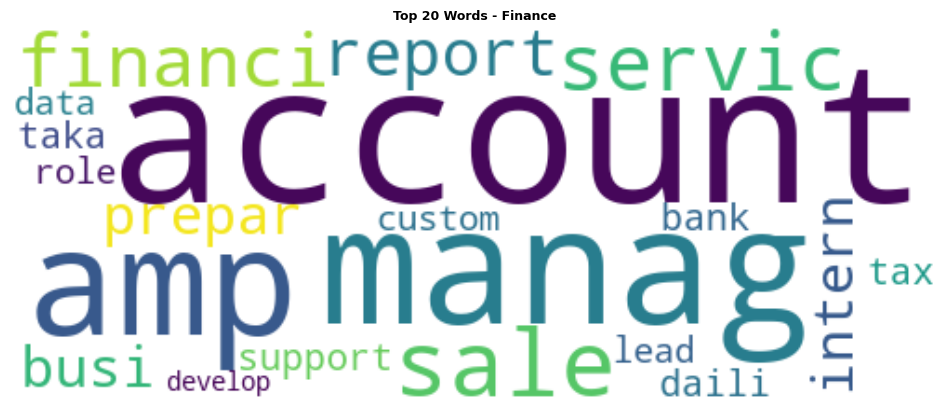

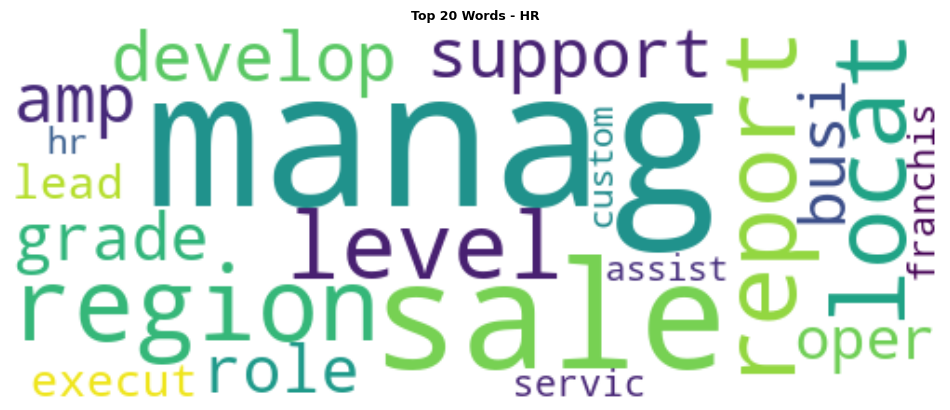

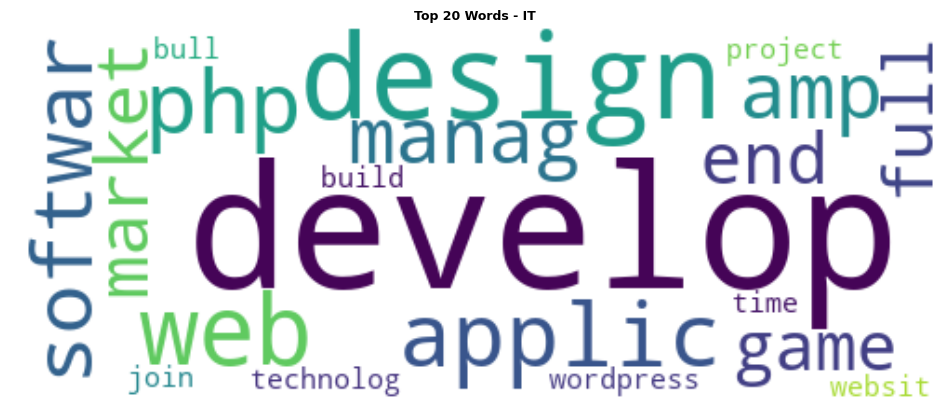

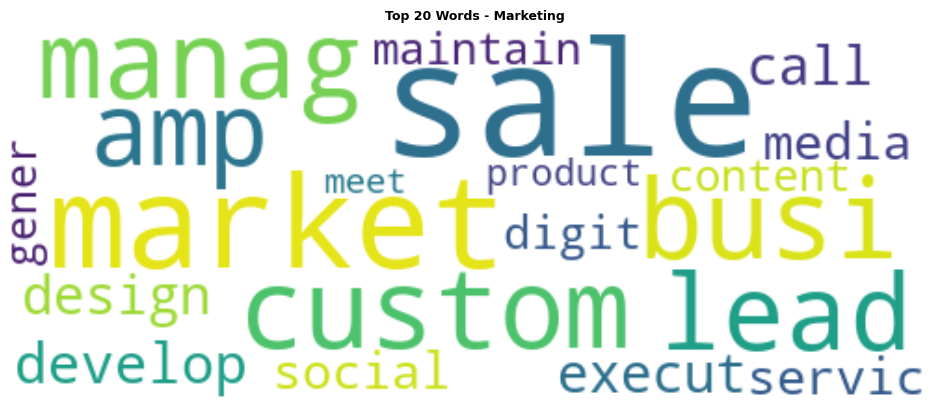

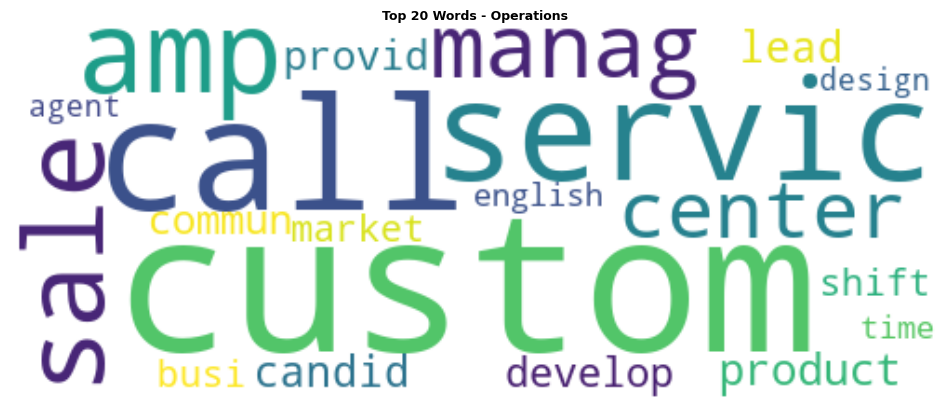

In [210]:
### Generate Word Clouds (Top 20 Words)
categories = sorted(df["Category"].unique())

for category in categories:

    text = " ".join(
        df[df["Category"] == category]["Cleaned_JD"]
    )

    wordcloud = WordCloud(
        width=500,
        height=200,
        background_color="white",
        max_words=20,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(12,6))

    plt.imshow(wordcloud, interpolation="bilinear")

    plt.title(f"Top 20 Words - {category}",
              fontsize=9,
              fontweight="bold")

    plt.axis("off")

    plt.show()

In [211]:
### Top 20 Most Frequent Words per Category
from collections import Counter

for category in sorted(df["Category"].unique()):

    text = " ".join(df[df["Category"] == category]["Cleaned_JD"])

    words = text.split()

    common_words = Counter(words).most_common(20)

    print("\n" + "="*70)
    print(f"Top 20 Words - {category}")
    print("="*70)

    for word, count in common_words:
        print(f"{word:<20} {count}")


Top 20 Words - Finance
account              159
manag                107
amp                  90
sale                 82
servic               63
financi              58
report               50
busi                 35
prepar               35
intern               34
support              34
daili                33
taka                 33
tax                  32
bank                 31
custom               28
role                 27
lead                 27
data                 26
develop              26

Top 20 Words - HR
manag                118
sale                 65
region               65
report               62
locat                61
level                60
develop              60
support              59
amp                  59
grade                54
role                 53
busi                 51
oper                 45
execut               43
lead                 42
servic               41
franchis             40
assist               39
custom               39
hr                

In [ ]:
#### Feature extraction (convert text into numbers)

In [212]:
### spliting data 
from sklearn.model_selection import train_test_split

X = df["Cleaned_JD"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4652,)
(1164,)


In [213]:
### Count Vectorizer (counts how many times each word appears)
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

print(X_train_count.shape)

(4652, 6811)


In [214]:
#### TF-IDF (count words & gives higher importance to informative words and lower importance to common words)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(4652, 5000)


In [51]:
#### Model Training 

In [136]:
### loading required packages 
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

In [215]:
### Create a Reusable Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    return accuracy, f1

In [182]:
### Evaluate on Count Vectorizer
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

count_results = []

for name, model in models.items():

    accuracy, f1 = evaluate_model(
        model,
        X_train_count,
        X_test_count,
        y_train,
        y_test
    )

    count_results.append([name, accuracy, f1])

In [220]:
### Evaluate on TF-IDF Vectorizer
tfidf_results = []

for name, model in models.items():

    accuracy, f1 = evaluate_model(
        model,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )

    tfidf_results.append([
        "TF-IDF",
        name,
        accuracy,
        f1
    ])

In [221]:
import pandas as pd
comparison = pd.DataFrame(
    count_results + tfidf_results,
    columns=[
        "Vectorizer",
        "Model",
        "Accuracy",
        "Weighted F1"
    ]
)
comparison

,Vectorizer,Model,Accuracy,Weighted F1
0,Count Vectorizer,Naive Bayes,0.709622,0.708666
1,Count Vectorizer,Logistic Regression,0.768041,0.760325
2,Count Vectorizer,Linear SVM,0.757732,0.752407
3,TF-IDF,Naive Bayes,0.689863,0.648296
4,TF-IDF,Logistic Regression,0.725945,0.705109
5,TF-IDF,Linear SVM,0.768900,0.760893


In [222]:
### best Model 
best_model = LinearSVC(
    random_state=42,
    max_iter=10000
)

best_model.fit(X_train_tfidf, y_train)

LinearSVC(max_iter=10000, random_state=42)

In [223]:
### Clssification report 
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Finance       0.66      0.70      0.68        61
          HR       0.83      0.54      0.65        71
          IT       0.82      0.93      0.87       602
   Marketing       0.63      0.53      0.58       203
  Operations       0.72      0.66      0.69       227

    accuracy                           0.77      1164
   macro avg       0.73      0.67      0.69      1164
weighted avg       0.76      0.77      0.76      1164



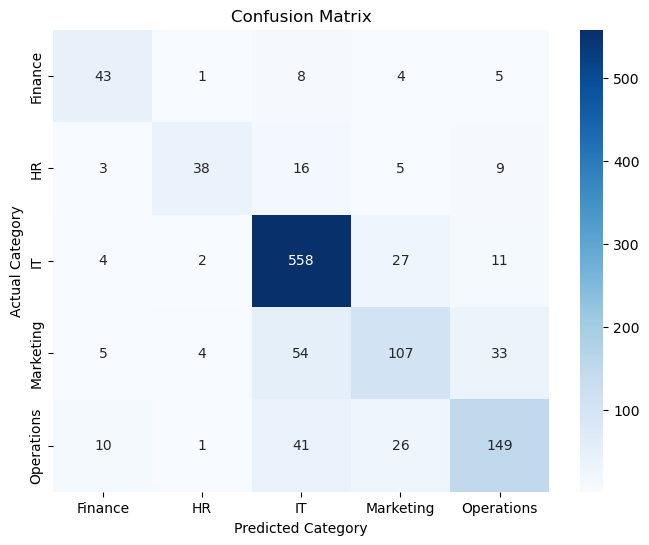

In [224]:
### confusion matrix heatmap 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

In [225]:
### Top 10 Most Informative Words per Category
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()

for i, category in enumerate(best_model.classes_):

    print("="*70)
    print(f"Category: {category}")
    print("="*70)

    top10 = np.argsort(best_model.coef_[i])[-10:]

    for j in reversed(top10):
        print(feature_names[j])

Category: Finance
account
financi
bank
taka
insur
risk
assur
audit
manag corpor
tax
Category: HR
receptionist
level locat
administr
duti includ
intern recruit
custom relat
nbsp
book
hyderabad
sindhi
Category: IT
develop
hunt
ppc
attend
startup
softwar
game
crm
full time
shift time
Category: Marketing
sale person
news
market
hire seo
target
segment
establish
sale
design rough
site site
Category: Operations
bpo
control
earn
construct
civil
autocad
materi
inbound
fashion
lab


In [226]:
### Train a Probability Model
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=10000
    ),
    cv=5
)

calibrated_model.fit(X_train_tfidf, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=LinearSVC(max_iter=10000, random_state=42))

In [227]:
## Prediction Function
import re
import string

def predict_category(job_description_text):

    cleaned = preprocess_text(job_description_text)

    vector = tfidf_vectorizer.transform([cleaned])

    prediction = calibrated_model.predict(vector)[0]

    probabilities = calibrated_model.predict_proba(vector)

    confidence = probabilities.max() * 100

    print("Predicted Category :", prediction)
    print(f"Confidence : {confidence:.2f}%")

    return prediction, confidence

In [228]:
### Test on 5 Real Job Descriptions (kaggle dataset)
sample_jobs = df[["Job Name","JD","Category"]].sample(
    5,
    random_state=42
)
sample_jobs

,Job Name,JD,Category
393,Full Time SEO Specialist Jobs in Pakistan,"We are looking for a driven, technical mind to...",IT
3588,Full Time Arabic - Email/ Chat Support Executi...,Interact with customers to provide and process...,Operations
4439,Full Time Marketin/Sales Officer Job in Pakistan,We are looking for a Sales Officer / Sales Exe...,Marketing
1817,Full Time Senior PHP Developer Job in Pakistan,A Dubai base company is looking for an experie...,IT
168,Full Time Territory Sales Supervisor Job in Pa...,What is a Territory Sales Supervisor?TSS team ...,Marketing


In [230]:
### Predict on the 5 Jobs
results = []

for _, row in sample_jobs.iterrows():

    cleaned = preprocess_text(row["JD"])

    vector = tfidf_vectorizer.transform([cleaned])

    prediction = calibrated_model.predict(vector)[0]

    confidence = calibrated_model.predict_proba(vector).max() * 100

    results.append([
        row["Job Name"],
        row["Category"],
        prediction,
        round(confidence,2)
    ])

prediction_results = pd.DataFrame(
    results,
    columns=[
        "Job Name",
        "Actual Category",
        "Predicted Category",
        "Confidence (%)"
    ]
)

prediction_results

,Job Name,Actual Category,Predicted Category,Confidence (%)
0,Full Time SEO Specialist Jobs in Pakistan,IT,IT,85.71
1,Full Time Arabic - Email/ Chat Support Executi...,Operations,Operations,85.47
2,Full Time Marketin/Sales Officer Job in Pakistan,Marketing,Marketing,78.63
3,Full Time Senior PHP Developer Job in Pakistan,IT,IT,89.32
4,Full Time Territory Sales Supervisor Job in Pa...,Marketing,Marketing,85.77
